## Feature Engineering

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder

In [2]:
import matplotlib.style as _ms

# Patch for mplcyberpunk expecting matplotlib.style.core
if not hasattr(_ms, "core"):
    _ms.core = _ms

import mplcyberpunk as mpl

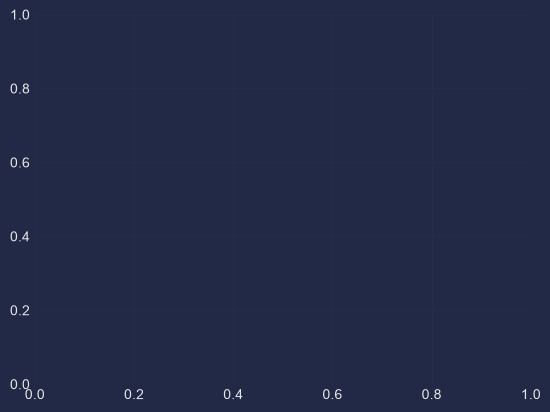

In [3]:
load_dotenv()
plt.style.use('cyberpunk')
mpl.add_glow_effects()

In [4]:
test = pd.read_csv('data/ev_purchase/test.csv', index_col='id')
train = pd.read_csv('data/ev_purchase/train.csv', index_col='id')

### Feature Engineering

In [5]:
## Ordinal Encoding

ordinal_cols = ['Gender', 'Home_Charging_Possible', 'Subsidy_Available']

ordinal_encoder = OrdinalEncoder()

train[ordinal_cols] = ordinal_encoder.fit_transform(train[ordinal_cols])
test[ordinal_cols] = ordinal_encoder.transform(test[ordinal_cols])

# transform the target variable 'Will_Buy_EV' to binary values
label_encoder = LabelEncoder()
train['Will_Buy_EV'] = label_encoder.fit_transform(train['Will_Buy_EV'])

In [6]:
## OneHot Encoding
one_hot_cols = ['City_Type', 'Range_Anxiety_Level', 'Current_Car_Type']

one_hot_encoder = OneHotEncoder()

columns = one_hot_encoder.fit(train[one_hot_cols]).get_feature_names_out(one_hot_cols)

train_onehot = one_hot_encoder.fit_transform(train[one_hot_cols])
test_one_hot = one_hot_encoder.transform(test[one_hot_cols])

train = pd.concat([train, pd.DataFrame(train_onehot.toarray(), columns=columns, index=train.index)], axis=1).drop(columns=one_hot_cols)
test = pd.concat([test, pd.DataFrame(test_one_hot.toarray(), columns=columns, index=test.index)], axis=1).drop(columns=one_hot_cols)


In [7]:
train['Total_Station'] = train['Charging_Stations_Near_Home'] + train['Charging_Stations_Near_Work']
train['Charge_Available'] = train['Total_Station'] > 0
train['Is_First_Car'] = train['Number_of_Cars_Owned'] == 1

In [8]:
test['Total_Station'] = test['Charging_Stations_Near_Home'] + test['Charging_Stations_Near_Work']
test['Charge_Available'] = test['Total_Station'] > 0
test['Is_First_Car'] = test['Number_of_Cars_Owned'] == 1

In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    train.drop(columns=['Will_Buy_EV']),
    train['Will_Buy_EV'],
    test_size=0.2,
    random_state=42
)

In [10]:
# let's prepare the data
# 1. use small piece of the training data ( 1000 rows ) to speed up the hyperparameter optimization process
X_train_small, _, y_train_small, _ = train_test_split(
    X_train,
    y_train,
    train_size=1000,
    random_state=42
)

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [55]:
best_params =  {'n_estimators': 425, 'max_depth': 22, 'min_samples_split': 7, 'min_samples_leaf': 4, 'criterion': 'entropy'}

estimator = RandomForestClassifier(
    **best_params,
    random_state=42,
    n_jobs=-1
)

In [56]:
estimator.fit(X_train_small, y_train_small)

feature_importance = estimator.feature_importances_

fe_df = pd.DataFrame(
    {'Feature': X_train_small.columns,
     'Importance': feature_importance}
).sort_values(by='Importance', ascending=False)

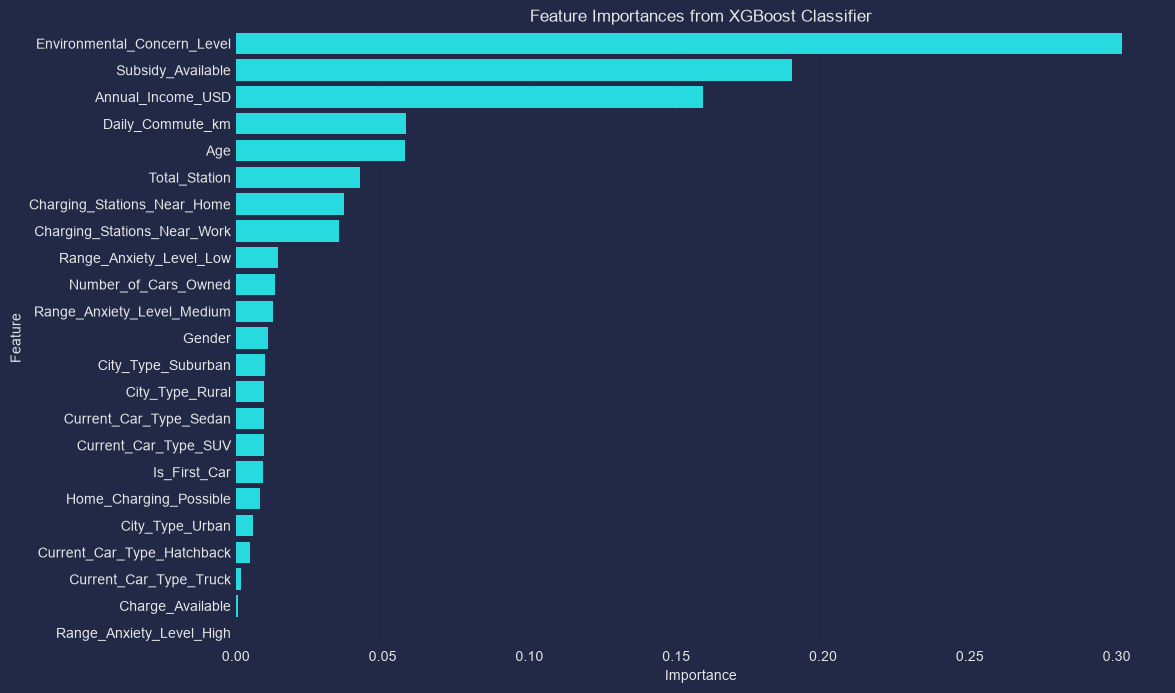

In [57]:
# Plot feature importances for Random Forest
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=fe_df)
plt.title('Feature Importances from Random Forest Classifier')
plt.show()

In [58]:
# use Optuna to optimize hyperparameters of the Random Forest model
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 10, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
    }

    model = RandomForestClassifier(**params, random_state=42)

    # Manually iterate CV folds so we can report intermediate results per fold
    # (cross_val_score runs all folds at once and gives no chance to prune mid-way).
    scores = []
    for step, (train_idx, valid_idx) in enumerate(cv.split(X_train_small, y_train_small)):
        X_fold_train, X_fold_valid = X_train_small.iloc[train_idx], X_train_small.iloc[valid_idx]
        y_fold_train, y_fold_valid = y_train_small.iloc[train_idx], y_train_small.iloc[valid_idx]

        model.fit(X_fold_train, y_fold_train)
        fold_accuracy = model.score(X_fold_valid, y_fold_valid)
        scores.append(fold_accuracy)

        # Report the running mean accuracy after each fold so the pruner can
        # compare this trial's progress against other trials at the same step.
        trial.report(np.mean(scores), step)

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    accuracy = np.mean(scores)

    return accuracy

In [59]:
# Stop the whole study early if no trial has improved the best score
# in the last `patience` completed trials (cross-trial early stopping).
def early_stopping_callback(study, trial, patience=25):
    best_trial = study.best_trial
    trials_since_best = trial.number - best_trial.number

    if trials_since_best >= patience:
        print(f'No improvement in {patience} trials, stopping study early.')
        study.stop()


pruner = optuna.pruners.MedianPruner()
study = optuna.create_study(direction='maximize',
                            study_name='RandomForest_Optimization',
                            sampler=optuna.samplers.TPESampler(seed=42),
                            pruner=pruner)

study.optimize(objective,
               n_trials=200,
               n_jobs=-1,
               callbacks=[early_stopping_callback],
               show_progress_bar=True)

print("Best hyperparameters: ", study.best_params)

[I 2026-09-19 21:15:03,309] A new study created in memory with name: RandomForest_Optimization


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-09-19 21:15:09,708] Trial 15 finished with value: 0.8960000000000001 and parameters: {'n_estimators': 104, 'max_depth': 14, 'min_samples_split': 8, 'min_samples_leaf': 1, 'criterion': 'entropy'}. Best is trial 15 with value: 0.8960000000000001.
[I 2026-09-19 21:15:10,384] Trial 3 finished with value: 0.892 and parameters: {'n_estimators': 121, 'max_depth': 26, 'min_samples_split': 8, 'min_samples_leaf': 2, 'criterion': 'gini'}. Best is trial 15 with value: 0.8960000000000001.
[I 2026-09-19 21:15:12,071] Trial 8 finished with value: 0.8880000000000001 and parameters: {'n_estimators': 154, 'max_depth': 11, 'min_samples_split': 18, 'min_samples_leaf': 3, 'criterion': 'gini'}. Best is trial 15 with value: 0.8960000000000001.
[I 2026-09-19 21:15:12,233] Trial 2 finished with value: 0.891 and parameters: {'n_estimators': 154, 'max_depth': 24, 'min_samples_split': 9, 'min_samples_leaf': 2, 'criterion': 'gini'}. Best is trial 15 with value: 0.8960000000000001.
[I 2026-09-19 21:15:13,19

In [38]:
best_score = study.best_value
best_params = study.best_params
print(f'Best cross-validated accuracy for RandomForest_Optimization: {best_score:.4f}')
print("Best hyperparameters for RandomForest_Optimization: ", best_params)

Best cross-validated accuracy for RandomForest_Optimization: 0.8980
Best hyperparameters for RandomForest_Optimization:  {'n_estimators': 170, 'max_depth': 27, 'min_samples_split': 6, 'min_samples_leaf': 4, 'criterion': 'entropy'}


In [78]:

score_list = []
max_num_features = len(test.columns)

estimator = RandomForestClassifier(**best_params)

for k in range(1, max_num_features + 1):
    rfe = RFE(
        estimator=estimator,
        n_features_to_select=k,
        step=5,
        verbose=0,
    )

    X_train_sel = rfe.fit_transform(X_train_small, y_train_small)
    X_valid_sel = rfe.transform(X_val)

    estimator.fit(X_train_sel, y_train_small)
    y_pred = estimator.predict_proba(X_valid_sel)[:, 1]

    acc_score = accuracy_score(y_val, (y_pred > 0.5).astype(int))

    print(f'[!] Run: {k}/ {max_num_features} Accuracy: {acc_score}, Num features: {k}', end='\r')
    score_list.append(acc_score)

print(f'Best run: {score_list.index(max(score_list)) + 1}/{max_num_features} Accuracy: {max(score_list)}')

In [80]:
# Features selected and their corresponding Accuracy scores
list(zip(range(1, max_num_features +1 ), score_list))

[(1, 0.833062893975309),
 (2, 0.84057039025521),
 (3, 0.882938392169472),
 (4, 0.8834094800834499),
 (5, 0.8869239454734433),
 (6, 0.8874847644186551),
 (7, 0.8873576454577404),
 (8, 0.8870660196062303),
 (9, 0.8876268385514421),
 (10, 0.8911936470429886),
 (11, 0.891829241847562),
 (12, 0.8914553625507541),
 (13, 0.8910216625664571),
 (14, 0.8896457867542042),
 (15, 0.889346683316758),
 (16, 0.8904533660353091),
 (17, 0.8908646332617978),
 (18, 0.8910141849805209),
 (19, 0.8897803833010551),
 (20, 0.8901318298400545),
 (21, 0.8895560557229704),
 (22, 0.8888606402309078),
 (23, 0.8887335212699932)]

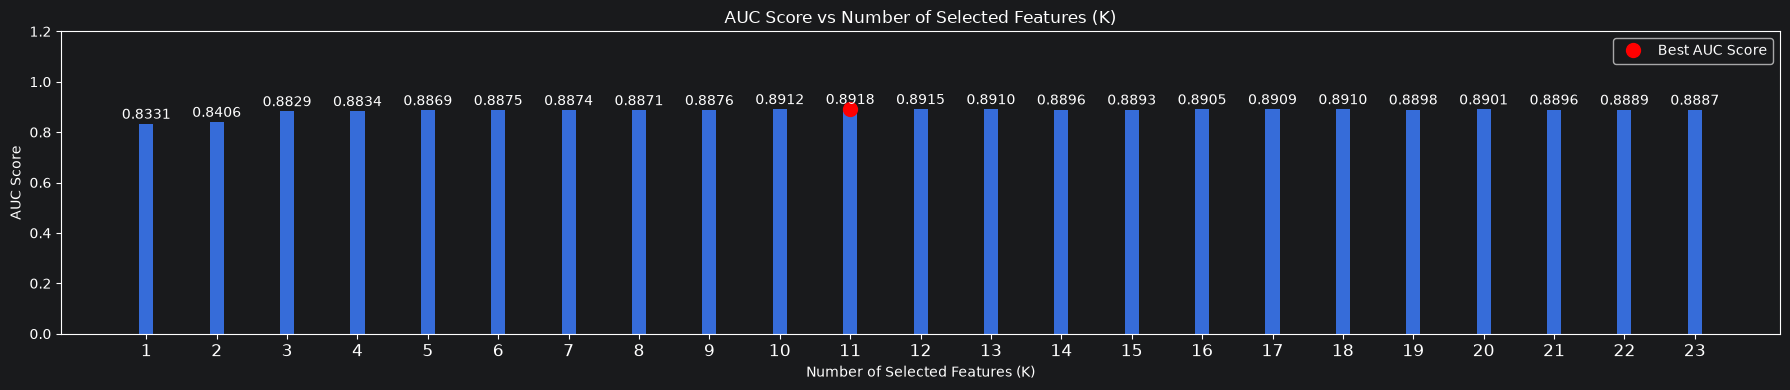

In [81]:
fig, ax = plt.subplots()
fig.set_size_inches(18, 4)
x = list(range(1, X_train_small.shape[1]+1))
y = score_list

ax.bar(x, y, width=0.2)
ax.set_xlabel('Number of Selected Features (K)')
ax.set_ylabel('AUC Score')
ax.set_xticks(x)
ax.set_xticklabels(x, fontsize=12)
ax.set_ylim(0, 1.2)

for index, value in enumerate(y):
    ax.text(x=index + 1, y=value + 0.02, s=f"{value:.4f}", ha='center', fontsize=10)

# mark best Accuracy score with a red dot
best_k = score_list.index(max(score_list)) + 1
best_acc = max(score_list)
ax.plot(best_k, best_acc, 'ro', markersize=10, label='Best Accuracy Score')
ax.legend()

plt.title('Accuracy Score vs Number of Selected Features (K)')
plt.tight_layout()
plt.show()

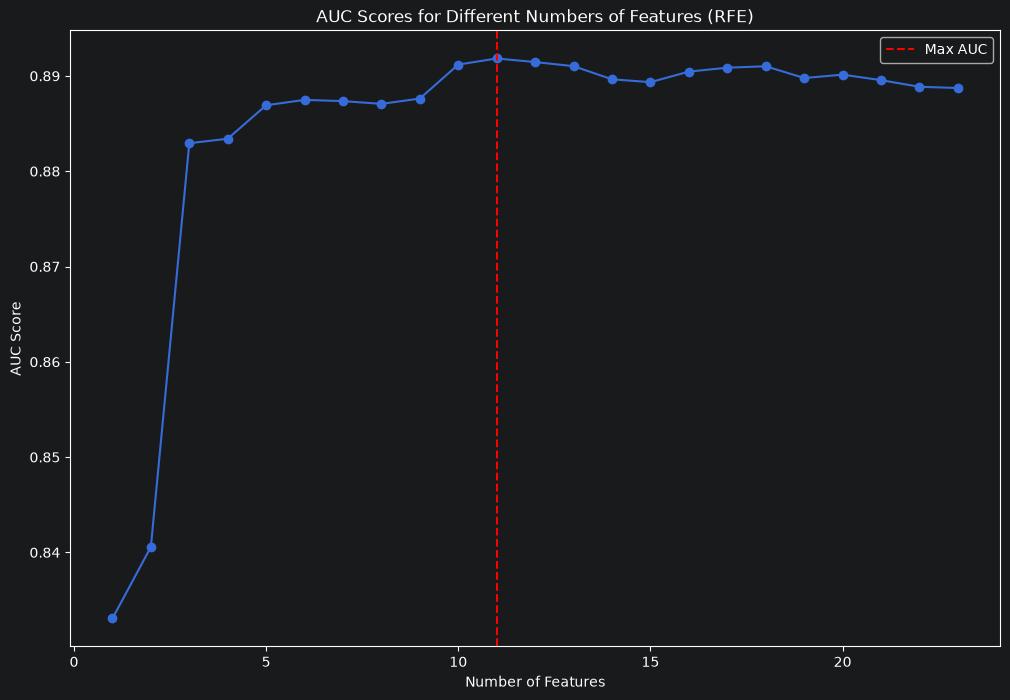

In [82]:
# visualize the Accuracy scores for different numbers of features ( vertical line at the maximum Accuracy score )

plt.figure(figsize=(12, 8))
plt.plot(range(1, max_num_features + 1), score_list, marker='o')
plt.title('Accuracy Scores for Different Numbers of Features (RFE)')
plt.xlabel('Number of Features')
plt.ylabel('Accuracy Score')
plt.axvline(x=score_list.index(max(score_list)) + 1, color='r', linestyle='--', label='Max Accuracy')
plt.legend()
plt.show()

In [83]:
best_features = list(X_train_small.columns[rfe.support_])

In [12]:
best_features = ['Age',
 'Annual_Income_USD',
 'Daily_Commute_km',
 'Number_of_Cars_Owned',
 'Charging_Stations_Near_Home',
 'Charging_Stations_Near_Work',
 'Environmental_Concern_Level',
 'Gender',
 'Home_Charging_Possible',
 'Subsidy_Available',
 'City_Type_Rural',
 'City_Type_Suburban',
 'City_Type_Urban',
 'Range_Anxiety_Level_High',
 'Range_Anxiety_Level_Low',
 'Range_Anxiety_Level_Medium',
 'Current_Car_Type_Hatchback',
 'Current_Car_Type_SUV',
 'Current_Car_Type_Sedan',
 'Current_Car_Type_Truck',
 'Total_Station',
 'Charge_Available',
 'Is_First_Car']

In [84]:
model = RandomForestClassifier(**best_params)

cv_scores = cross_val_score(model,
							X_train[best_features],
							y_train,
							cv=cv,
                            n_jobs=-1,
							scoring='accuracy')
accuracy = cv_scores.mean()
print(f'Mean cross-train accuracy for RandomForest_Optimization: {accuracy:.4f}')

Mean cross-train accuracy for RandomForest_Optimization: 0.8960


In [85]:
cv_scores = cross_val_score(model,
							X_val[best_features],
							y_val,
							cv=cv,
                            n_jobs=-1,
							scoring='accuracy')
accuracy = cv_scores.mean()
print(f'Mean cross-validated accuracy for RandomForest_Optimization: {accuracy:.4f}')

Mean cross-validated accuracy for RandomForest_Optimization: 0.8960


In [13]:
from xgboost import XGBClassifier

estimator = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

estimator.fit(
    X_train[best_features], y_train
)

acc = accuracy_score(y_val, estimator.predict(X_val[best_features]))
print(f'XGBoost accuracy on validation set: {acc:.4f}')

XGBoost accuracy on validation set: 0.8982


In [14]:
estimator = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

estimator.fit(
    X_train, y_train
)

acc = accuracy_score(y_val, estimator.predict(X_val))
print(f'XGBoost accuracy on validation set: {acc:.4f}')

XGBoost accuracy on validation set: 0.8982
